# Final clustering choices

## 1. Reducing dimensionality

### 1.1 Why reduce dimensionality before clustering?

I have my matrix X of dimensions (129, 298) and i want to prove that as dimensionality increases the distance to nearest neighbour approaches the dsitance to the farthest neighbour. So what i want is to make a sequence of matrices starting from my matrix X so that the first matrix has just the first column, the second matrix the first 2 columns and so on . Then for each such "sub matrix" i want a distance matrix containing the euclidian distances between all possible pairings of the 129 rows. and then for each of the distance matrices i want the maximum distance value (max_k) and the minimum distance value (min_l) and make the ratio min_k / max_k and plot the result.

In [2]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    # grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    grew_pattern="pattern {X[upos]}",
    # patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    patterns_text_file="/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt",
    matrix_type="coverage"
)

connected to port: 63087


Number of matches after filtering: 331353


In [3]:
X = corpus.feature_matrix
print(X.shape)

(2948, 443)


min_k: 6.507434092695163e-07, max_k: 0.0514018691588785 for k=1
min_k: 1.1188944707111695e-06, max_k: 0.0589310021584176 for k=2
min_k: 5.692770295578908e-07, max_k: 0.06030124680015412 for k=3
min_k: 5.692770295578908e-07, max_k: 0.06030124680015412 for k=4
min_k: 5.692770295578908e-07, max_k: 0.06030124680015412 for k=5
min_k: 5.692770295578908e-07, max_k: 0.06030124680015412 for k=6
min_k: 1.1188944707111695e-06, max_k: 0.060315555317384445 for k=7
min_k: 1.1188944707111695e-06, max_k: 0.06031612758747131 for k=8
min_k: 1.1188944707111695e-06, max_k: 0.06031612758747131 for k=9
min_k: 1.1188944707111695e-06, max_k: 0.06031612758747131 for k=10
min_k: 1.1188944707111695e-06, max_k: 0.06031612758747131 for k=11
min_k: 1.1188944707111695e-06, max_k: 0.06031612758747131 for k=12
min_k: 1.1188944707111695e-06, max_k: 0.06031612758747131 for k=13
min_k: 1.1188944707111695e-06, max_k: 0.06031669985212862 for k=14
min_k: 1.1188944707111695e-06, max_k: 0.06031669985212862 for k=15
min_k: 7.6

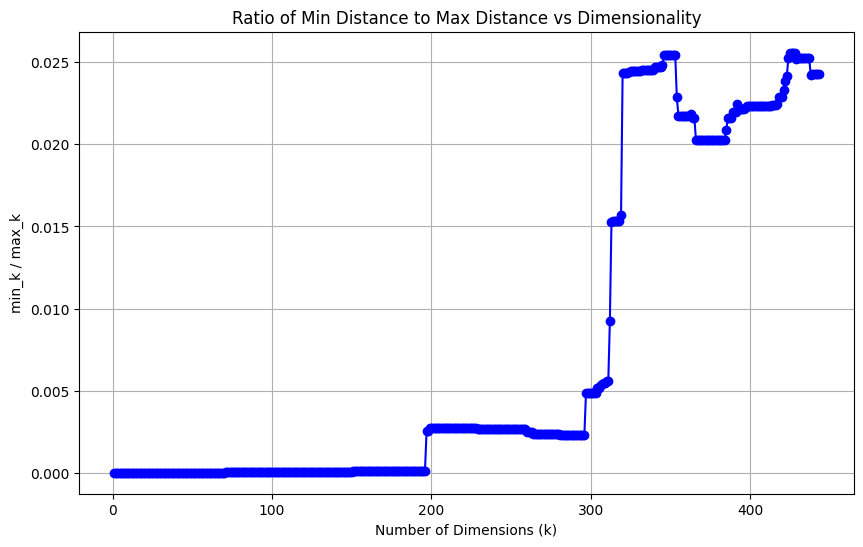

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Initialize lists to store the results
ratios = []
dimensions = []
mins_list, maxs_list = [], []

# Iterate over the number of columns (1 to 298)
for k in range(1, X.shape[1] + 1):
    # Create the sub-matrix with the first k columns
    sub_matrix = X[:, :k]
    
    # Compute the pairwise Euclidean distance matrix
    distance_matrix = cdist(sub_matrix, sub_matrix, metric='euclidean')
    
    # Get the minimum and maximum distances (excluding self-distances)
    np.fill_diagonal(distance_matrix, np.nan)  # Ignore diagonal (self-distances)
    distance_matrix [distance_matrix == 0] = np.nan  # Ignore zero distances
    min_k = np.nanmin(distance_matrix)
    max_k = np.nanmax(distance_matrix)
    print(f"min_k: {min_k}, max_k: {max_k} for k={k}")
    # Compute the ratio min_k / max_k
    if max_k > 0:  # Avoid division by zero
        ratio = min_k / max_k
    else:
        ratio = 0.0
    ratios.append(ratio)
    dimensions.append(k)
    mins_list.append(min_k)
    maxs_list.append(max_k)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(dimensions, ratios, marker='o', linestyle='-', color='b')
plt.title('Ratio of Min Distance to Max Distance vs Dimensionality')
plt.xlabel('Number of Dimensions (k)')
plt.ylabel('min_k / max_k')
plt.grid()
plt.show()

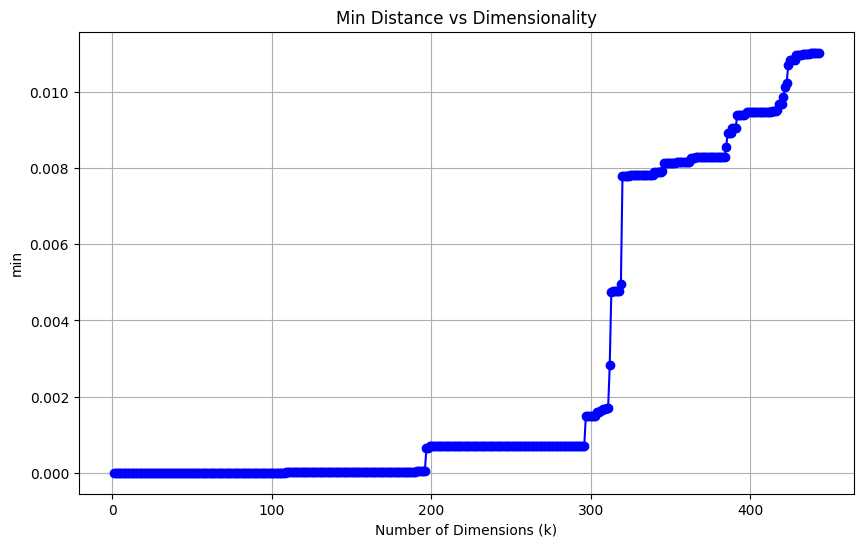

In [8]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(dimensions, mins_list, marker='o', linestyle='-', color='b')
plt.title('Min Distance vs Dimensionality')
plt.xlabel('Number of Dimensions (k)')
plt.ylabel('min')
plt.grid()
plt.show()

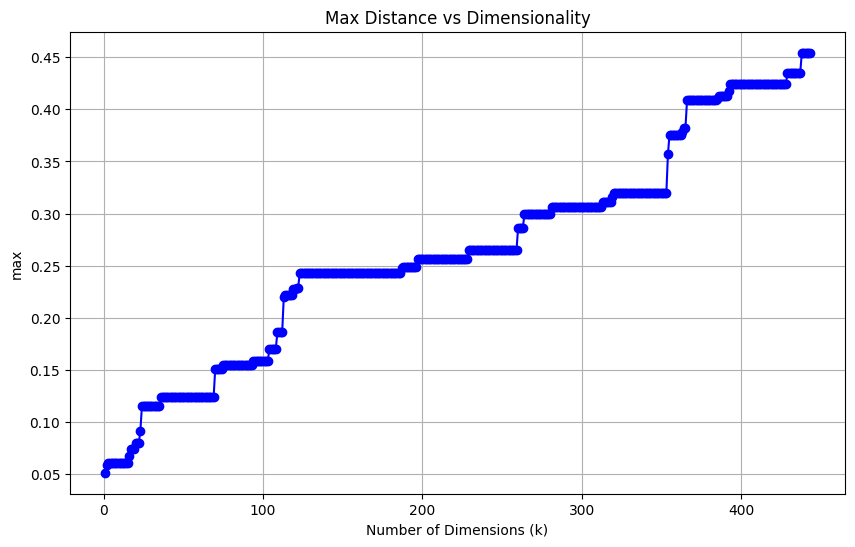

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(dimensions, maxs_list, marker='o', linestyle='-', color='b')
plt.title('Max Distance vs Dimensionality')
plt.xlabel('Number of Dimensions (k)')
plt.ylabel('max')
plt.grid()
plt.show()

### 1.2. Reducing dimensionality using explainable steps

One way of reducing the dimensionality of our matrix would be to select features that are important, and remove those that are not. While at first glance it may seem like this approach will lead to information loss, in our case many of the features are highly correlated (for example in the case of an adverb having a verb as governor, besides the governor's upos being "verb" we would also have features related to mood and tense which are highly correlated with the upos being verb).

The natural question at this point is how do we determine feature importance. One approach presented in detail by Heiml is to classify each feature based on its frequency, variability and nonrandomness. Frequency relies on the principle that a feature should describe a behaviour that occurs often enough for it to make a substantial contribution to our understanding of the data. Variability is based on the fact that the values of each feature should vary significantly, the idea being that if there is no variability for a certain feature than that feature does not help us distinguish between data points and is therefore useless for our purposes. Finally, nonrandomness is based on the fact that a feature would have to have a non random distribution of variability among the data points for it to be useful for clustering purposes.

In [6]:
###########FREQUENCY###########
import plotly.graph_objects as go
import numpy as np

frequency_matrix = corpus.co_occurrence_matrix
print(frequency_matrix.shape)
# Step 1: Sum the values in each column
column_sums = np.sum(frequency_matrix, axis=0)

# Step 2: Sort the values and keep track of their original indices
sorted_indices = np.argsort(column_sums)
sorted_values = column_sums[sorted_indices]

# Create an interactive bar plot using Plotly
fig = go.Figure()

# Add a bar trace with custom hover text
fig.add_trace(go.Bar(
    x=list(range(len(sorted_values))),
    y=sorted_values,
    hovertext=sorted_indices,  # Show original index on hover
    marker_color='blue'
))

# Update layout for better presentation
fig.update_layout(
    title='Sorted Feature Frequencies',
    xaxis_title='Feature Index',
    yaxis_title='Total Occurrences',
    # xaxis=dict(tickmode='linear'),
    hovermode='closest'
)

# Show the plot
fig.show()
 

(129, 298)


In [72]:
fig.write_html("sorted_feature_frequencies.html")

In [7]:
for idx in sorted_indices:
    print(corpus.idx2feature(idx), column_sums[idx])

node:X:child:rel_shallow=dep 1.0
node:X:child:rel_shallow=flat:name 1.0
node:X:child:rel_shallow=aux:tense 1.0
node:X:child:rel_shallow=orphan 1.0
node:X:prev:NumType=Ord 1.0
node:X:child:Subject=OblRaising 1.0
node:X:child:Reflex=Yes 1.0
node:X:child:PronType=Int 1.0
node:X:parent:Reflex=Yes 1.0
node:X:child:Poss=Yes 1.0
node:X:child:Person__psor=3 1.0
node:X:prev:PronType=Exc 1.0
node:X:child:Number__psor=Sing 1.0
node:X:own:rel_shallow=acl 1.0
node:X:own:rel_shallow=obj:lvc 1.0
node:X:next:upos=INTJ 1.0
node:X:own:PronType=Rel 1.0
node:X:next:Subject=OblRaising 1.0
node:X:child:ExtPos=CCONJ 1.0
node:X:child:ExtPos=SCONJ 1.0
node:X:next:upos=SYM 1.0
node:X:child:ExtPos=ADP 2.0
node:X:child:Subject=ObjRaising 2.0
node:X:prev:Number__psor=Plur 2.0
node:X:parent:Definite=Ind 2.0
node:X:parent:PronType=Exc 2.0
node:X:child:ExtPos=PROPN 2.0
node:X:child:rel_shallow=parataxis 2.0
node:X:parent:upos=AUX 2.0
node:X:child:Mood=Cnd 2.0
node:X:own:Polarity=Pos 3.0
node:X:prev:ExtPos=ADP 3.0
nod

In [8]:
###########VARIABILITY###########

X_coverage = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
).feature_matrix

X_precision = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="precision"
).feature_matrix

X_pmi = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="PMI"
).feature_matrix

X_tfidf = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="tf-idf"
).feature_matrix

X_geometric_mean = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="geometric_mean"
).feature_matrix

Number of matches after filtering: 11701
Number of matches after filtering: 11701
Number of matches after filtering: 11701
Number of matches after filtering: 11701
Number of matches after filtering: 11701


In [23]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate variance for each column in the matrices
variances = {
    "Coverage": np.var(X_coverage, axis=0),
    "Precision": np.var(X_precision, axis=0),
    "PMI": np.var(X_pmi, axis=0),
    "TF-IDF": np.var(X_tfidf, axis=0),
    "Geometric Mean": np.var(X_geometric_mean, axis=0),
}

# Create subplots
fig = make_subplots(rows=5, cols=1, subplot_titles=list(variances.keys()), shared_xaxes=True)

# Add bar plots for each matrix
for i, (name, var) in enumerate(variances.items(), start=1):
    sorted_indices = np.argsort(var)  # Get indices that would sort the variance
    sorted_variances = var[sorted_indices]  # Sort variances
    sorted_features = [corpus.idx2feature(idx) for idx in sorted_indices]  # Map indices to features
    fig.add_trace(
        go.Bar(
            x=list(range(len(sorted_variances))),
            y=sorted_variances,
            text=sorted_features,  # Feature names
            hovertemplate="Feature: %{text}<br>Variance: %{y}<extra></extra>",
        ),
        row=i,
        col=1,
    )

# Update layout
fig.update_layout(
    height=1500,  # Adjust height for better visualization
    title="Variance per Column for Each Matrix",
    showlegend=False,
)

# Show plot
fig.show()

In [81]:
fig.write_html("variance_per_column.html")

In [10]:
import pandas as pd

# Create a dictionary to store features sorted by variance for each matrix
least_varying_features = {}

for name, var in variances.items():
    sorted_indices = np.argsort(var)  # Indices of features sorted by variance (ascending)
    sorted_features = [corpus.idx2feature(idx) for idx in sorted_indices]  # Map indices to features
    least_varying_features[name] = sorted_features  # Store sorted features for this matrix

# Create a DataFrame to display the top least varying features for each matrix
num_features_to_display = len(sorted_indices) # Adjust this to show more or fewer features
table_data = {
    matrix_name: features[:num_features_to_display]
    for matrix_name, features in least_varying_features.items()
}

# Convert to a pandas DataFrame
df = pd.DataFrame(table_data)

# Display the table
print("Top least varying features for each matrix:")
print(df)

Top least varying features for each matrix:
                             Coverage                           Precision  \
0             node:X:child:Reflex=Yes              node:X:prev:Tense=Past   
1        node:X:child:rel_shallow=dep           node:X:prev:VerbForm=Part   
2            node:X:prev:PronType=Exc            node:X:prev:VerbForm=Inf   
3      node:X:next:Subject=OblRaising              node:X:next:Voice=Pass   
4          node:X:parent:PronType=Exc               node:X:prev:Voice=Act   
..                                ...                                 ...   
293     node:X:parent:position=before  node:X:child:rel_shallow=flat:name   
294     node:X:own:rel_shallow=advmod      node:X:own:rel_shallow=obj:lvc   
295  node:X:child:rel_shallow=obl:arg          node:X:own:rel_shallow=acl   
296              node:X:next:upos=ADP                node:X:next:upos=SYM   
297      node:X:parent:position=after     node:X:child:Subject=OblRaising   

                              P

In [1]:
###########NON RANDOMNESS###########
frequency_matrix = corpus.co_occurrence_matrix
means = np.mean(frequency_matrix, axis=0)  # Mean for each column
variances = np.var(frequency_matrix, axis=0)  # Variance for each column
vmr = variances / means
feature_names = [corpus.idx2feature(idx) for idx in range(frequency_matrix.shape[1])]  # Map indices to feature names
vmr_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean": means,
    "Variance": variances,
    "VMR": vmr
})

NameError: name 'corpus' is not defined

In [12]:
import plotly.graph_objects as go

# Get feature names using corpus.idx2feature
feature_names = [corpus.idx2feature(idx) for idx in range(frequency_matrix.shape[1])]

# Create a scatter plot for VMR values
fig = go.Figure(
    data=go.Scatter(
        x=list(range(len(vmr))),  # Indices of features
        y=vmr,  # VMR values
        mode="markers",
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>VMR: %{y}<extra></extra>",
        marker=dict(
            size=8,
            color=vmr,  # Color based on VMR values
            colorscale="Viridis",
            colorbar=dict(title="VMR"),
        ),
    )
)

# Update layout
fig.update_layout(
    title="Variance-to-Mean Ratio (VMR) for Features",
    xaxis_title="Feature Index",
    yaxis_title="VMR",
    height=600,
    width=1000,
)

# Show plot
fig.show()

In [13]:
import plotly.graph_objects as go

# Get feature names using corpus.idx2feature
feature_names = [corpus.idx2feature(idx) for idx in range(frequency_matrix.shape[1])]

# Create a bar plot for VMR values
fig = go.Figure(
    data=go.Bar(
        x=list(range(len(vmr))),  # Indices of features
        y=vmr,  # VMR values
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>VMR: %{y}<extra></extra>",
        marker=dict(
            color=vmr,  # Color based on VMR values
            colorscale="Viridis",
            colorbar=dict(title="VMR"),
        ),
    )
)

# Update layout
fig.update_layout(
    title="Variance-to-Mean Ratio (VMR) for Features",
    xaxis_title="Feature Index",
    yaxis_title="VMR",
    height=600,
    width=1000,
)

# Show plot
fig.show()

In [14]:
# Step 4: Filter features based on VMR
# Features with VMR close to 1 are likely Poisson-like
threshold = 0.1  # Define a threshold for "closeness" to 1
poisson_like_features = vmr_df[np.abs(vmr_df["VMR"] - 1) < threshold]  # Features close to Poisson
non_random_features = vmr_df[np.abs(vmr_df["VMR"] - 1) >= threshold]  # Features significantly non-random

# Display results
print("Features close to Poisson distribution (to be removed):")
print(poisson_like_features)

print("\nFeatures significantly non-random (to be kept):")
print(non_random_features)

Features close to Poisson distribution (to be removed):
                                Feature      Mean  Variance       VMR
3                 node:X:child:Emph=Yes  0.038760  0.037257  0.961240
6             node:X:child:ExtPos=CCONJ  0.007752  0.007692  0.992248
9             node:X:child:ExtPos=PROPN  0.015504  0.015264  0.984496
10            node:X:child:ExtPos=SCONJ  0.007752  0.007692  0.992248
13                node:X:child:Mood=Cnd  0.015504  0.015264  0.984496
18       node:X:child:Number__psor=Sing  0.007752  0.007692  0.992248
19                node:X:child:Person=1  0.023256  0.022715  0.976744
20                node:X:child:Person=2  0.038760  0.037257  0.961240
22          node:X:child:Person__psor=3  0.007752  0.007692  0.992248
24                node:X:child:Poss=Yes  0.007752  0.007692  0.992248
28            node:X:child:PronType=Int  0.007752  0.007692  0.992248
31              node:X:child:Reflex=Yes  0.007752  0.007692  0.992248
33      node:X:child:Subject=ObjRa

## FINAL COMBINATION OF THEM ALL

In [25]:
frequency_matrix = corpus.co_occurrence_matrix
# Step 1: Sum the values in each column
column_sums = np.sum(frequency_matrix, axis=0)

# Step 2: Sort the values and keep track of their original indices
frequency_sorted_indices = np.argsort(column_sums)
frequency_sorted_values = column_sums[frequency_sorted_indices]

# var_sorted_indices = np.argsort(variances['PMI'])
var_sorted_indices = np.argsort(variances['PMI'])  # Get indices that would sort the variance
var_sorted_values = variances['PMI'][var_sorted_indices]  # Sort variances

vmr_sorted_indices = np.argsort(vmr_df['VMR'])
vmr_sorted_values = vmr_df['VMR'][vmr_sorted_indices] 



In [26]:
import numpy as np
import pandas as pd
import plotly.express as px

# Step 1: Z-standardize the values for comparability
def z_standardize(values):
    return (values - np.mean(values)) / np.std(values)

# Z-standardize the three measures
z_column_sums = z_standardize(column_sums)
z_var_sorted_values = z_standardize(var_sorted_values)
z_vmr_sorted_values = z_standardize(vmr_df['VMR'])

# Step 2: Create a DataFrame for visualization
feature_names = [corpus.idx2feature(idx) for idx in range(frequency_matrix.shape[1])]
data = pd.DataFrame({
    "Feature": feature_names,
    "Z-Column Sums": z_column_sums,
    "Z-Variance (PMI)": z_var_sorted_values,
    "Z-VMR": z_vmr_sorted_values
})

# Step 3: Create a scatter plot matrix
fig = px.scatter_matrix(
    data,
    dimensions=["Z-Column Sums", "Z-Variance (PMI)", "Z-VMR"],
    hover_name="Feature",  # Show feature name on hover
    title="Scatter Plot Matrix of Z-Standardized Measures",
    labels={"value": "Z-Standardized Value"}
)

# Update layout for better readability
fig.update_layout(
    height=800,
    width=800,
    title_font_size=16,
    hoverlabel=dict(font_size=12)
)

# Show plot
fig.show()

In [27]:
import plotly.graph_objects as go

# Create a figure
fig = go.Figure()

# Add traces for each measure with different symbols
fig.add_trace(
    go.Scatter(
        x=list(range(len(z_column_sums))),  # Feature indices
        y=z_column_sums,  # Z-standardized column sums
        mode="markers",
        name="Z-Column Sums",
        marker=dict(symbol="circle", size=8),
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>Z-Column Sums: %{y}<extra></extra>",
    )
)

fig.add_trace(
    go.Scatter(
        x=list(range(len(z_var_sorted_values))),  # Feature indices
        y=z_var_sorted_values,  # Z-standardized variances
        mode="markers",
        name="Z-Variance (PMI)",
        marker=dict(symbol="square", size=8),
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>Z-Variance (PMI): %{y}<extra></extra>",
    )
)

fig.add_trace(
    go.Scatter(
        x=list(range(len(z_vmr_sorted_values))),  # Feature indices
        y=z_vmr_sorted_values,  # Z-standardized VMR
        mode="markers",
        name="Z-VMR",
        marker=dict(symbol="triangle-up", size=8),
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>Z-VMR: %{y}<extra></extra>",
    )
)

# Update layout
fig.update_layout(
    title="Comparison of Z-Standardized Measures for Features",
    xaxis_title="Feature Index",
    yaxis_title="Z-Standardized Value",
    height=600,
    width=1000,
    legend_title="Measures",
    hoverlabel=dict(font_size=12),
)

# Show plot
fig.show()

In [28]:
import plotly.graph_objects as go

# Create a figure
fig = go.Figure()

# Add traces for each measure with different symbols
fig.add_trace(
    go.Scatter(
        x=list(range(len(z_column_sums))),  # Feature indices
        y=z_column_sums,  # Z-standardized column sums
        mode="markers",
        name="Z-Column Sums",
        marker=dict(symbol="circle", size=8),
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>Z-Column Sums: %{y}<extra></extra>",
    )
)

fig.add_trace(
    go.Scatter(
        x=list(range(len(z_var_sorted_values))),  # Feature indices
        y=z_var_sorted_values,  # Z-standardized variances
        mode="markers",
        name="Z-Variance (PMI)",
        marker=dict(symbol="square", size=8),
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>Z-Variance (PMI): %{y}<extra></extra>",
    )
)

fig.add_trace(
    go.Scatter(
        x=list(range(len(z_vmr_sorted_values))),  # Feature indices
        y=z_vmr_sorted_values,  # Z-standardized VMR
        mode="markers",
        name="Z-VMR",
        marker=dict(symbol="triangle-up", size=8),
        text=feature_names,  # Feature names for hover
        hovertemplate="Feature: %{text}<br>Z-VMR: %{y}<extra></extra>",
    )
)

# Add horizontal red lines for the range [1, 6]
fig.add_trace(
    go.Scatter(
        x=[-1, len(z_column_sums)],  # Extend beyond the x-axis range
        y=[1, 1],  # Horizontal line at y=1
        mode="lines",
        line=dict(color="red"),
        name="Lower Bound (1)",
        hoverinfo="skip",  # No hover info for the line
    )
)

fig.add_trace(
    go.Scatter(
        x=[-1, len(z_column_sums)],  # Extend beyond the x-axis range
        y=[6, 6],  # Horizontal line at y=6
        mode="lines",
        line=dict(color="red"),
        name="Upper Bound (6)",
        hoverinfo="skip",  # No hover info for the line
    )
)

# Update layout
fig.update_layout(
    title="Comparison of Z-Standardized Measures for Features",
    xaxis_title="Feature Index",
    yaxis_title="Z-Standardized Value",
    height=600,
    width=1000,
    legend_title="Measures",
    hoverlabel=dict(font_size=12),
)

# Show plot
fig.show()

In [144]:
# get features where the values for all z columns are between 1 and 6
filtered_data = data[
    # (data["Z-Column Sums"] >= 1) & (data["Z-Column Sums"] <= 6) 
    (data["Z-Variance (PMI)"] >= 1) & (data["Z-Variance (PMI)"] <= 6) 
    # (data["Z-VMR"] >= 1) & (data["Z-VMR"] <= 6)
]
filtered_data

,Feature,Z-Column Sums,Z-Variance (PMI),Z-VMR
12,node:X:child:Gender=Masc,0.074786,2.011415,-0.125399
14,node:X:child:Mood=Ind,-0.372916,1.311282,-0.360214
17,node:X:child:Number=Sing,0.140715,1.486430,0.102176
21,node:X:child:Person=3,-0.341485,1.207638,-0.356655
23,node:X:child:Polarity=Neg,-0.371383,1.051692,-0.357989
39,node:X:child:Tense=Pres,-0.375982,1.048176,-0.360124
40,node:X:child:VerbForm=Fin,-0.366016,1.134808,-0.360054
48,node:X:child:rel_shallow=advmod,0.051787,1.353914,-0.153828
52,node:X:child:rel_shallow=cc,-0.375982,1.208200,-0.368966
54,node:X:child:rel_shallow=conj,-0.403580,1.263753,-0.378945


In [36]:
data

,Feature,Z-Column Sums,Z-Variance (PMI),Z-VMR
0,node:X:child:Definite=Def,-0.408947,-1.851233,-0.346799
1,node:X:child:Definite=Ind,-0.409713,-1.851233,-0.343159
2,node:X:child:Emph=No,-0.423512,-1.851233,-0.378534
3,node:X:child:Emph=Yes,-0.426579,-1.847629,-0.382371
4,node:X:child:ExtPos=ADP,-0.428878,-1.841180,-0.376194
...,...,...,...,...
293,node:X:prev:upos=PUNCT,0.304003,2.365204,-0.222906
294,node:X:prev:upos=SCONJ,-0.390548,2.383336,-0.375283
295,node:X:prev:upos=SYM,-0.424279,2.579308,-0.374966
296,node:X:prev:upos=VERB,1.778965,2.755309,0.250881


### Actually remove the features

- For frequency, we remove:
    - features with less than 5 occurrences
    - any feats that have a single value and have very high or very low occurrences
    - any feats that have only 2 possible values - we remove one of the 2

In [60]:
import numpy as np

indices = frequency_sorted_indices
values = frequency_sorted_values
items = [corpus.idx2feature(idx) for idx in indices]
frequency_df = pd.DataFrame({
    "Feature": [i.split("=")[0] for i in items],
    "Value": [i.split("=")[1] for i in items],
    "Frequency": values
})

# frequency_df
# Calculate IQR
q1 = frequency_df['Frequency'].quantile(0.25)
q3 = frequency_df['Frequency'].quantile(0.75)
print(q1, q3)
iqr = q3 - q1

# Define lower and upper bounds
lower_bound = q1 - 2 * iqr
upper_bound = q3 + 2 * iqr
print(lower_bound, upper_bound)
# # Filter the DataFrame based on IQR
# clean_frequency_df = frequency_df[(frequency_df['Frequency'] >= lower_bound) & (frequency_df['Frequency'] <= upper_bound)]
# print(clean_frequency_df)

9.0 417.0
-807.0 1233.0


In [41]:
# Calculate the Median Absolute Deviation (MAD)
median = frequency_df['Frequency'].median()
print(median)
# mad = np.median(np.abs(frequency_df['Frequency'] - median))

# # Filter the DataFrame based on the Modified Z-score
# clean_frequency_df = frequency_df[frequency_df['Frequency'] <= median + 3 * mad]

# print(clean_frequency_df)

64.0


In [ ]:
frequency_df

In [ ]:
# # Identify features with a single possible value
# single_value_features = clean_frequency_df.groupby('Feature')['Value'].nunique()
# single_value_features = single_value_features[single_value_features == 1].index

# # Filter the DataFrame
# filtered_df = clean_frequency_df[((clean_frequency_df['Feature'].isin(single_value_features)))]

# print(filtered_df)

                      Feature   Value  Frequency
53       node:X:parent:ExtPos   PROPN        6.0
54          node:X:child:upos       X        6.0
55   node:X:next:Person__psor       1        6.0
56       node:X:next:PronType     Int        6.0
57       node:X:prev:PronType     Int        6.0
..                        ...     ...        ...
293        node:X:prev:Number    Sing     5367.0
294        node:X:parent:upos    VERB     6928.0
295      node:X:parent:Number    Sing     7511.0
296    node:X:parent:position   after     7796.0
297    node:X:own:rel_shallow  advmod    11124.0

[240 rows x 3 columns]


In [61]:
indices = frequency_sorted_indices
values = frequency_sorted_values
items = [corpus.idx2feature(idx) for idx in indices]
frequency_df = pd.DataFrame({
    "Feature": [i.split("=")[0] for i in items],
    "Value": [i.split("=")[1] for i in items],
    "Frequency": values
})


# Define lower and upper bounds
lower_bound = 100
upper_bound = 4500

clean_frequency_df = frequency_df[(frequency_df['Frequency'] >= lower_bound) & (frequency_df['Frequency'] <= upper_bound)]
clean_frequency_df

,Feature,Value,Frequency
180,node:X:own:rel_shallow,obl:mod,104.0
181,node:X:next:Reflex,Yes,111.0
182,node:X:parent:Person,2,113.0
183,node:X:prev:PronType,Rel,115.0
184,node:X:child:Person,3,116.0
...,...,...,...
287,node:X:prev:Mood,Ind,3832.0
288,node:X:parent:position,before,3905.0
289,node:X:parent:Gender,Masc,3934.0
290,node:X:prev:VerbForm,Fin,4000.0


In [46]:
# Identify features with exactly two possible values
two_value_features = clean_frequency_df.groupby('Feature')['Value'].nunique()
two_value_features = two_value_features[two_value_features == 2].index

# Filter the DataFrame to exclude one of the two possible values for these features
clean_frequency_df = clean_frequency_df[
    ~(
        (clean_frequency_df['Feature'].isin(two_value_features)) &
        (clean_frequency_df.duplicated(subset=['Feature'], keep='first'))
    )
]

clean_frequency_df

,Feature,Value,Frequency
180,node:X:own:rel_shallow,obl:mod,104.0
181,node:X:next:Reflex,Yes,111.0
182,node:X:parent:Person,2,113.0
183,node:X:prev:PronType,Rel,115.0
184,node:X:child:Person,3,116.0
...,...,...,...
285,node:X:parent:Person,3,3534.0
286,node:X:parent:VerbForm,Fin,3753.0
287,node:X:prev:Mood,Ind,3832.0
288,node:X:parent:position,before,3905.0


In [47]:
# Find the rows that were removed
removed_df = pd.merge(
    frequency_df,  # Original DataFrame
    clean_frequency_df,  # Cleaned DataFrame
    how='outer',  # Include all rows from both DataFrames
    indicator=True  # Add a column to indicate the source of each row
)

# Filter rows that are only in the original DataFrame
frequency_removed_df = removed_df[removed_df['_merge'] == 'left_only'].drop(columns=['_merge'])

frequency_removed_df

,Feature,Value,Frequency
0,node:X:child:rel_shallow,dep,1.0
1,node:X:child:rel_shallow,flat:name,1.0
2,node:X:child:rel_shallow,aux:tense,1.0
3,node:X:child:rel_shallow,orphan,1.0
4,node:X:prev:NumType,Ord,1.0
...,...,...,...
293,node:X:prev:Number,Sing,5367.0
294,node:X:parent:upos,VERB,6928.0
295,node:X:parent:Number,Sing,7511.0
296,node:X:parent:position,after,7796.0


For varibility we remove those with very low variability. So we choose the median and any under the median go.


In [48]:
indices = var_sorted_indices
values = var_sorted_values
items = [corpus.idx2feature(idx) for idx in indices]
var_df = pd.DataFrame({
    "Feature": [i.split("=")[0] for i in items],
    "Value": [i.split("=")[1] for i in items],
    "Variance": values,
    # "Z-Variance (PMI)": z_var_sorted_values
})

In [ ]:
var_df

In [49]:
# # Calculate the median of the Variance column
# variance_median = var_df['Variance'].median()

# # Filter out rows where Variance is lower than the median
# filtered_variance_df = var_df[var_df['Variance'] >= variance_median]

# filter the lowest 10% of the variance
num_rows = len(var_df)
first_25_percent = int(num_rows * 0.25)
filtered_variance_df = var_df[
    var_df['Variance'] >= var_df['Variance'].iloc[first_25_percent]
]

print(filtered_variance_df)

                    Feature  Value  Variance
74   node:X:parent:PronType    Int  0.261779
75    node:X:child:PronType    Int  0.262832
76      node:X:own:PronType    Rel  0.262832
77     node:X:next:Definite    Ind  0.263307
78   node:X:parent:Definite    Def  0.266056
..                      ...    ...       ...
293        node:X:next:Mood    Ind  0.946441
294        node:X:prev:upos    ADV  0.950405
295        node:X:next:upos  PUNCT  0.993249
296      node:X:parent:upos    ADJ  1.031728
297    node:X:next:VerbForm    Fin  1.043318

[224 rows x 3 columns]


In [50]:
# Find the rows that were removed
removed_df = pd.merge(
    var_df,  # Original DataFrame
    filtered_variance_df,  # Cleaned DataFrame
    how='outer',  # Include all rows from both DataFrames
    indicator=True  # Add a column to indicate the source of each row
)

# Filter rows that are only in the original DataFrame
var_removed_df = removed_df[removed_df['_merge'] == 'left_only'].drop(columns=['_merge'])

var_removed_df

,Feature,Value,Variance
0,node:X:child:Reflex,Yes,0.024620
1,node:X:child:rel_shallow,dep,0.024620
2,node:X:prev:PronType,Exc,0.024620
3,node:X:next:Mood,Imp,0.025408
4,node:X:next:Mood,Sub,0.026818
...,...,...,...
69,node:X:child:rel_shallow,obj,0.251387
70,node:X:child:rel_shallow,det,0.252844
71,node:X:prev:upos,INTJ,0.252949
72,node:X:child:ExtPos,SCONJ,0.259026


For non randomness

In [51]:
poisson_like_features

,Feature,Mean,Variance,VMR
3,node:X:child:Emph=Yes,0.038760,0.037257,0.961240
6,node:X:child:ExtPos=CCONJ,0.007752,0.007692,0.992248
9,node:X:child:ExtPos=PROPN,0.015504,0.015264,0.984496
10,node:X:child:ExtPos=SCONJ,0.007752,0.007692,0.992248
13,node:X:child:Mood=Cnd,0.015504,0.015264,0.984496
18,node:X:child:Number__psor=Sing,0.007752,0.007692,0.992248
19,node:X:child:Person=1,0.023256,0.022715,0.976744
20,node:X:child:Person=2,0.038760,0.037257,0.961240
22,node:X:child:Person__psor=3,0.007752,0.007692,0.992248
24,node:X:child:Poss=Yes,0.007752,0.007692,0.992248


In [52]:
combined_removed_df = pd.DataFrame({
    "Feature_frequency": frequency_removed_df["Feature"] + "=" + frequency_removed_df["Value"],
    "Feature_variance": var_removed_df["Feature"] + "=" + var_removed_df["Value"],
    "Feature_non_randomness": poisson_like_features["Feature"]
})

In [53]:
# Convert each column to a set
frequency_set = set(combined_removed_df["Feature_frequency"].dropna())
variance_set = set(combined_removed_df["Feature_variance"].dropna())
non_randomness_set = set(combined_removed_df["Feature_non_randomness"].dropna())

# Find intersections and differences
all_three = frequency_set & variance_set & non_randomness_set
frequency_variance_only = (frequency_set & variance_set) - non_randomness_set
frequency_non_randomness_only = (frequency_set & non_randomness_set) - variance_set
variance_non_randomness_only = (variance_set & non_randomness_set) - frequency_set
frequency_only = frequency_set - (variance_set | non_randomness_set)
variance_only = variance_set - (frequency_set | non_randomness_set)
non_randomness_only = non_randomness_set - (frequency_set | variance_set)

# Find the maximum length among all sets
max_length = max(
    len(all_three),
    len(frequency_variance_only),
    len(frequency_non_randomness_only),
    len(variance_non_randomness_only),
    len(frequency_only),
    len(variance_only),
    len(non_randomness_only)
)

# Pad each list with None to match the maximum length
summary_df = pd.DataFrame({
    "All_three": list(all_three) + [None] * (max_length - len(all_three)),
    "Frequency_and_Variance_only": list(frequency_variance_only) + [None] * (max_length - len(frequency_variance_only)),
    "Frequency_and_Non_randomness_only": list(frequency_non_randomness_only) + [None] * (max_length - len(frequency_non_randomness_only)),
    "Variance_and_Non_randomness_only": list(variance_non_randomness_only) + [None] * (max_length - len(variance_non_randomness_only)),
    "Frequency_only": list(frequency_only) + [None] * (max_length - len(frequency_only)),
    "Variance_only": list(variance_only) + [None] * (max_length - len(variance_only)),
    "Non_randomness_only": list(non_randomness_only) + [None] * (max_length - len(non_randomness_only))
})

summary_df

,All_three,Frequency_and_Variance_only,Frequency_and_Non_randomness_only,Variance_and_Non_randomness_only,Frequency_only,Variance_only,Non_randomness_only
0,node:X:child:Subject=ObjRaising,node:X:next:Subject=ObjRaising,node:X:next:Emph=Yes,None,node:X:child:rel_shallow=acl:relcl,node:X:prev:PronType=Art,None
1,node:X:parent:Definite=Ind,node:X:child:rel_shallow=appos,node:X:own:rel_shallow=acl,None,node:X:parent:upos=VERB,node:X:prev:upos=DET,None
2,node:X:child:rel_shallow=dep,node:X:prev:upos=SYM,node:X:next:ExtPos=SCONJ,None,node:X:next:upos=PROPN,node:X:next:Person=1,None
3,node:X:parent:PronType=Exc,node:X:prev:ExtPos=ADP,node:X:prev:ExtPos=PROPN,None,node:X:own:rel_shallow=obl:arg,node:X:next:Tense=Imp,None
4,node:X:own:rel_shallow=obj:lvc,node:X:parent:ExtPos=ADJ,node:X:next:ExtPos=PROPN,None,node:X:child:upos=AUX,node:X:prev:PronType=Rel,None
...,...,...,...,...,...,...,...
108,None,None,None,None,node:X:prev:Person=3,None,None
109,None,None,None,None,node:X:parent:Subject=ObjRaising,None,None
110,None,None,None,None,node:X:prev:Mood=Sub,None,None
111,None,None,None,None,node:X:child:VerbForm=Fin,None,None


In [54]:
import numpy as np

# Combine all features from the summary table into a single set
features_to_remove = set(
    summary_df["All_three"].dropna().tolist() +
    summary_df["Frequency_and_Variance_only"].dropna().tolist() +
    summary_df["Frequency_and_Non_randomness_only"].dropna().tolist() +
    summary_df["Variance_and_Non_randomness_only"].dropna().tolist() +
    summary_df["Frequency_only"].dropna().tolist() +
    summary_df["Variance_only"].dropna().tolist() +
    summary_df["Non_randomness_only"].dropna().tolist()
)

# Get the indices of features to remove using corpus.feature2idx
indices_to_remove = [corpus.feature2idx(feature) for feature in features_to_remove]

# Remove the columns from X
X_cleaned = np.delete(X, indices_to_remove, axis=1)  # axis=1 removes columns

print(f"Original shape of X: {X.shape}")
print(f"Shape of X after removal: {X_cleaned.shape}")

Original shape of X: (129, 298)
Shape of X after removal: (129, 89)


In [55]:
# import pandas as pd
# import numpy as np

# # Convert X to a DataFrame for easier manipulation (if it's not already)
# X_df = pd.DataFrame(X, columns=[corpus.idx2feature(idx) for idx in range(X.shape[1])])

# # Calculate the correlation matrix
# correlation_matrix = X_df.corr().abs()  # Absolute value of correlations

# # Identify highly correlated features (correlation > 0.9)
# threshold = 0.9
# highly_correlated = np.where(correlation_matrix > threshold)
# correlated_pairs = [
#     (correlation_matrix.index[i], correlation_matrix.columns[j])
#     for i, j in zip(*highly_correlated)
#     if i != j and i < j  # Avoid self-correlation and duplicate pairs
# ]

# # Create a set of features to remove
# features_to_remove_corr = set()
# for feature1, feature2 in correlated_pairs:
#     # Decide which feature to remove (e.g., keep the one with higher variance)
#     if X_df[feature1].var() > X_df[feature2].var():
#         features_to_remove_corr.add(feature2)
#     else:
#         features_to_remove_corr.add(feature1)

# # Map features to indices using corpus.feature2idx
# indices_to_remove_corr = [corpus.feature2idx(feature) for feature in features_to_remove_corr]

# # Combine with previously removed indices
# all_indices_to_remove = set(indices_to_remove + indices_to_remove_corr)

# # Remove the columns from X
# X_cleaned = np.delete(X, list(all_indices_to_remove), axis=1)

# print(f"Original shape of X: {X.shape}")
# print(f"Shape of X after removing highly correlated features: {X_cleaned.shape}")

Original shape of X: (129, 298)
Shape of X after removing highly correlated features: (129, 68)


In [168]:
[corpus.idx2feature(i) for i in all_indices_to_remove]

['node:X:child:Definite=Def',
 'node:X:child:Emph=No',
 'node:X:child:Emph=Yes',
 'node:X:child:ExtPos=ADP',
 'node:X:child:ExtPos=CCONJ',
 'node:X:child:ExtPos=NOUN',
 'node:X:child:ExtPos=PROPN',
 'node:X:child:ExtPos=SCONJ',
 'node:X:child:Gender=Fem',
 'node:X:child:Gender=Masc',
 'node:X:child:Mood=Cnd',
 'node:X:child:Mood=Ind',
 'node:X:child:Mood=Sub',
 'node:X:child:Number=Sing',
 'node:X:child:Number__psor=Sing',
 'node:X:child:Person=1',
 'node:X:child:Person=2',
 'node:X:child:Person=3',
 'node:X:child:Person__psor=3',
 'node:X:child:Poss=Yes',
 'node:X:child:PronType=Art',
 'node:X:child:PronType=Dem',
 'node:X:child:PronType=Int',
 'node:X:child:Reflex=Yes',
 'node:X:child:Subject=ObjRaising',
 'node:X:child:Subject=OblRaising',
 'node:X:child:Subject=SubjRaising',
 'node:X:child:Tense=Fut',
 'node:X:child:VerbForm=Inf',
 'node:X:child:VerbForm=Part',
 'node:X:child:Voice=Pass',
 'node:X:child:rel_shallow=acl:relcl',
 'node:X:child:rel_shallow=advcl',
 'node:X:child:rel_s

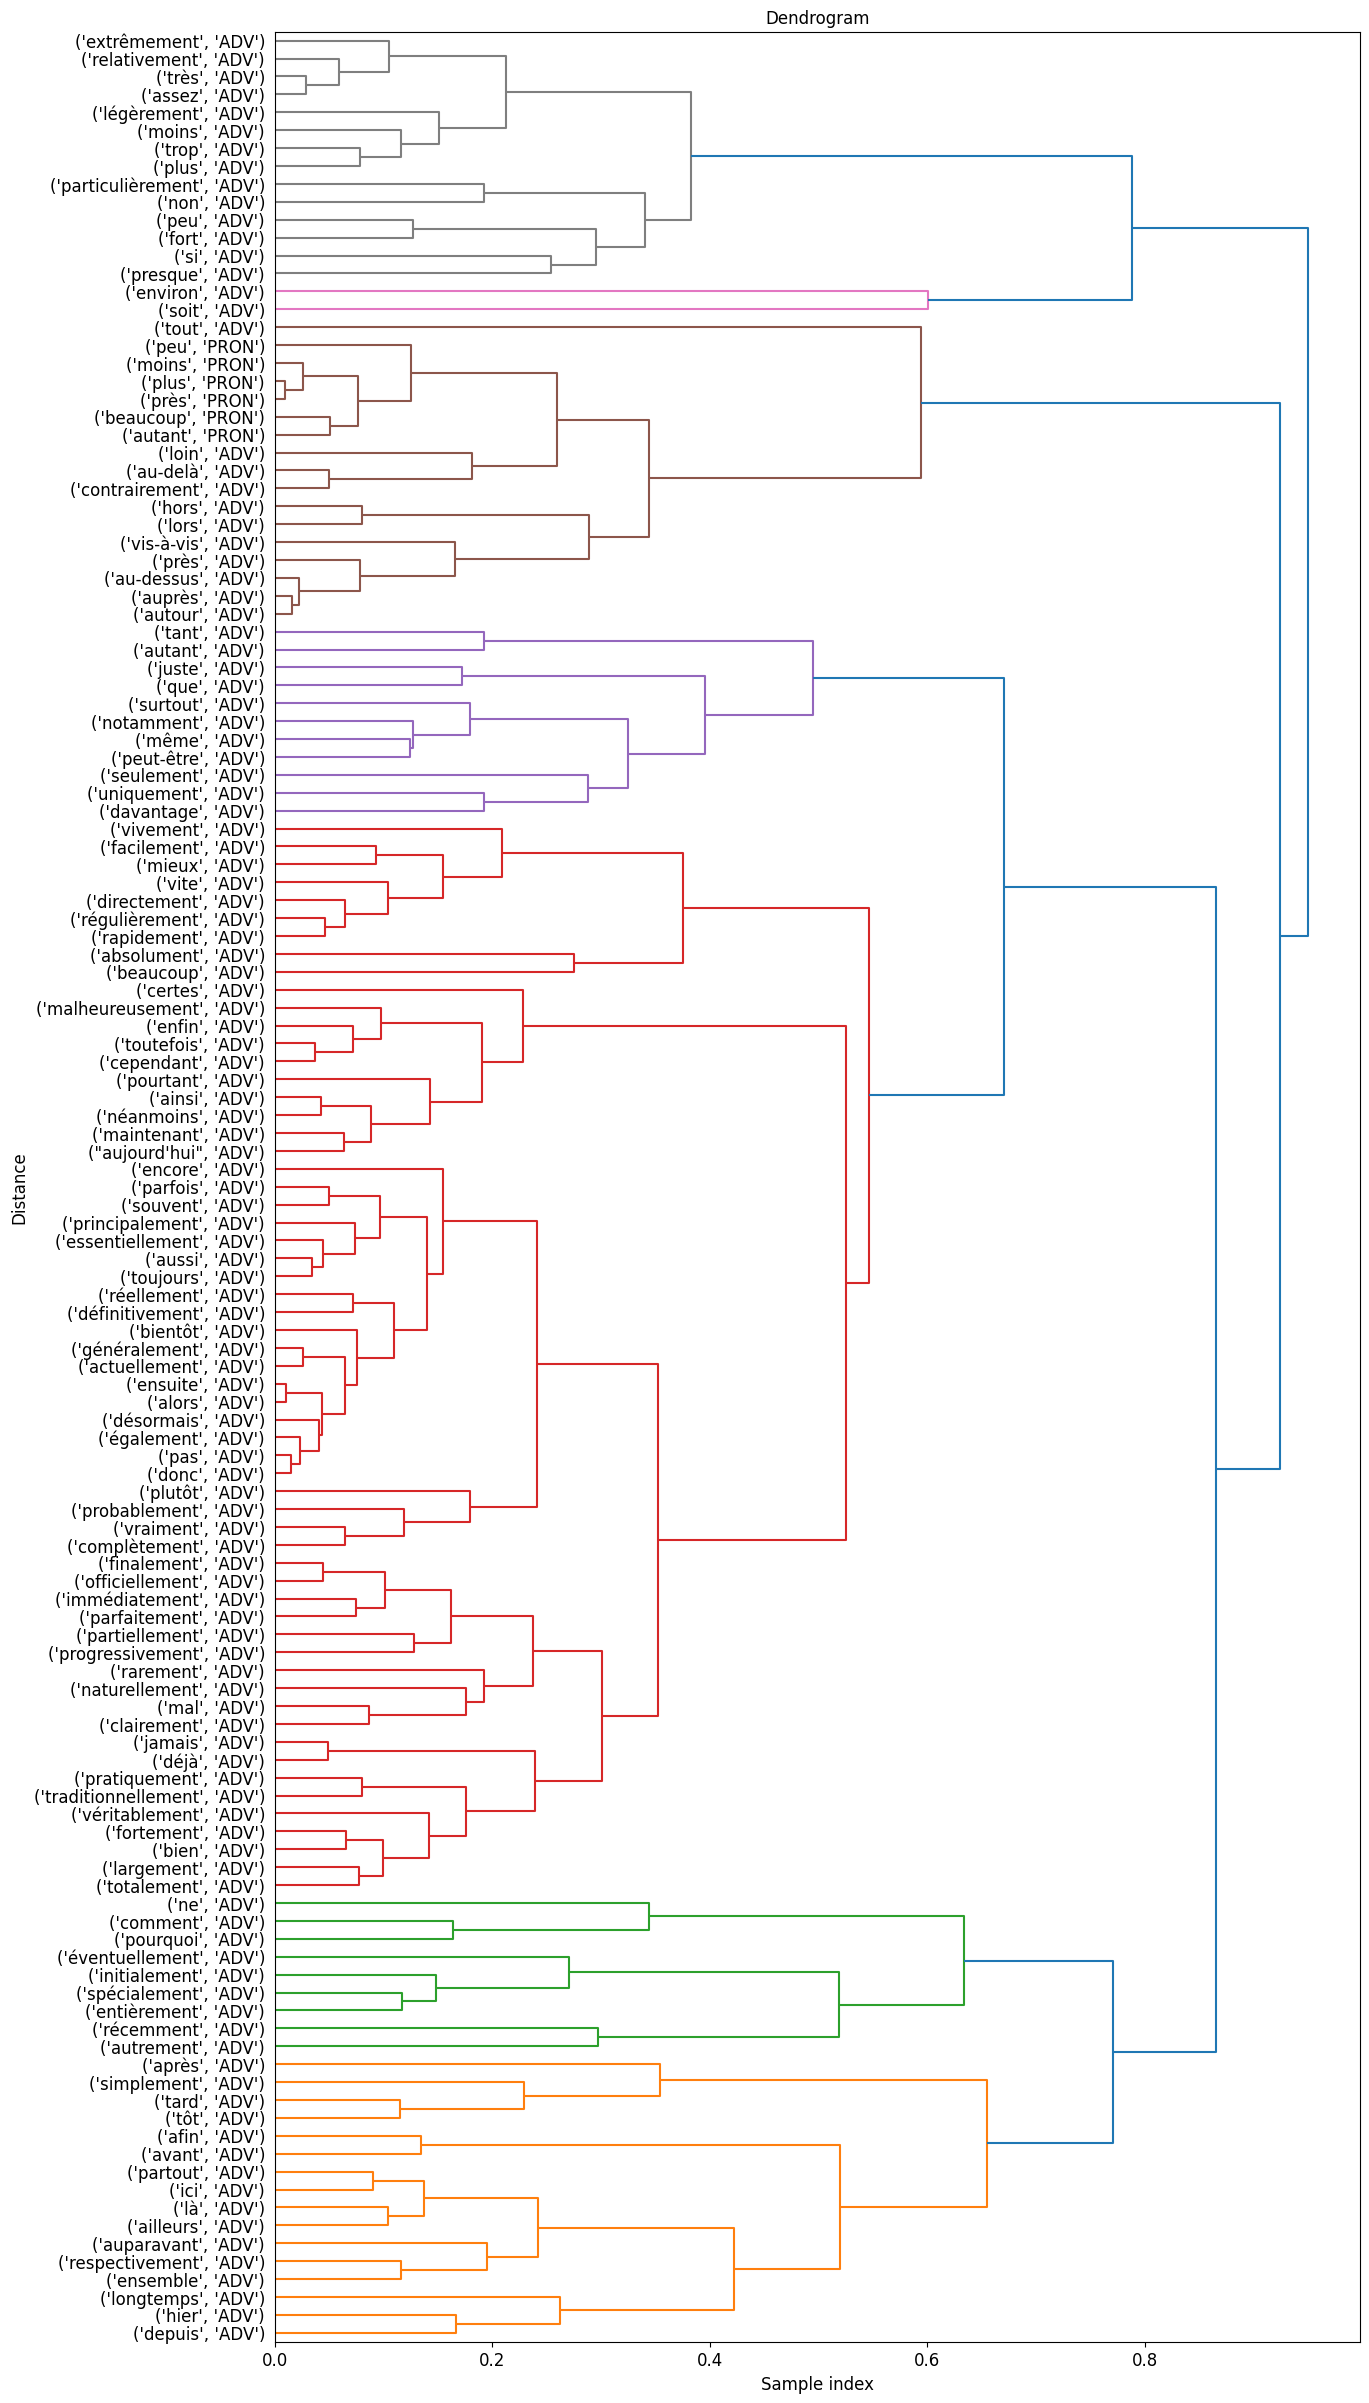

In [56]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

distance_matrix = pdist(X_cleaned, metric="cosine")
linked = linkage(
            distance_matrix, method="complete", optimal_ordering=True
        ) 


plt.figure(figsize=(14, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X_cleaned.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

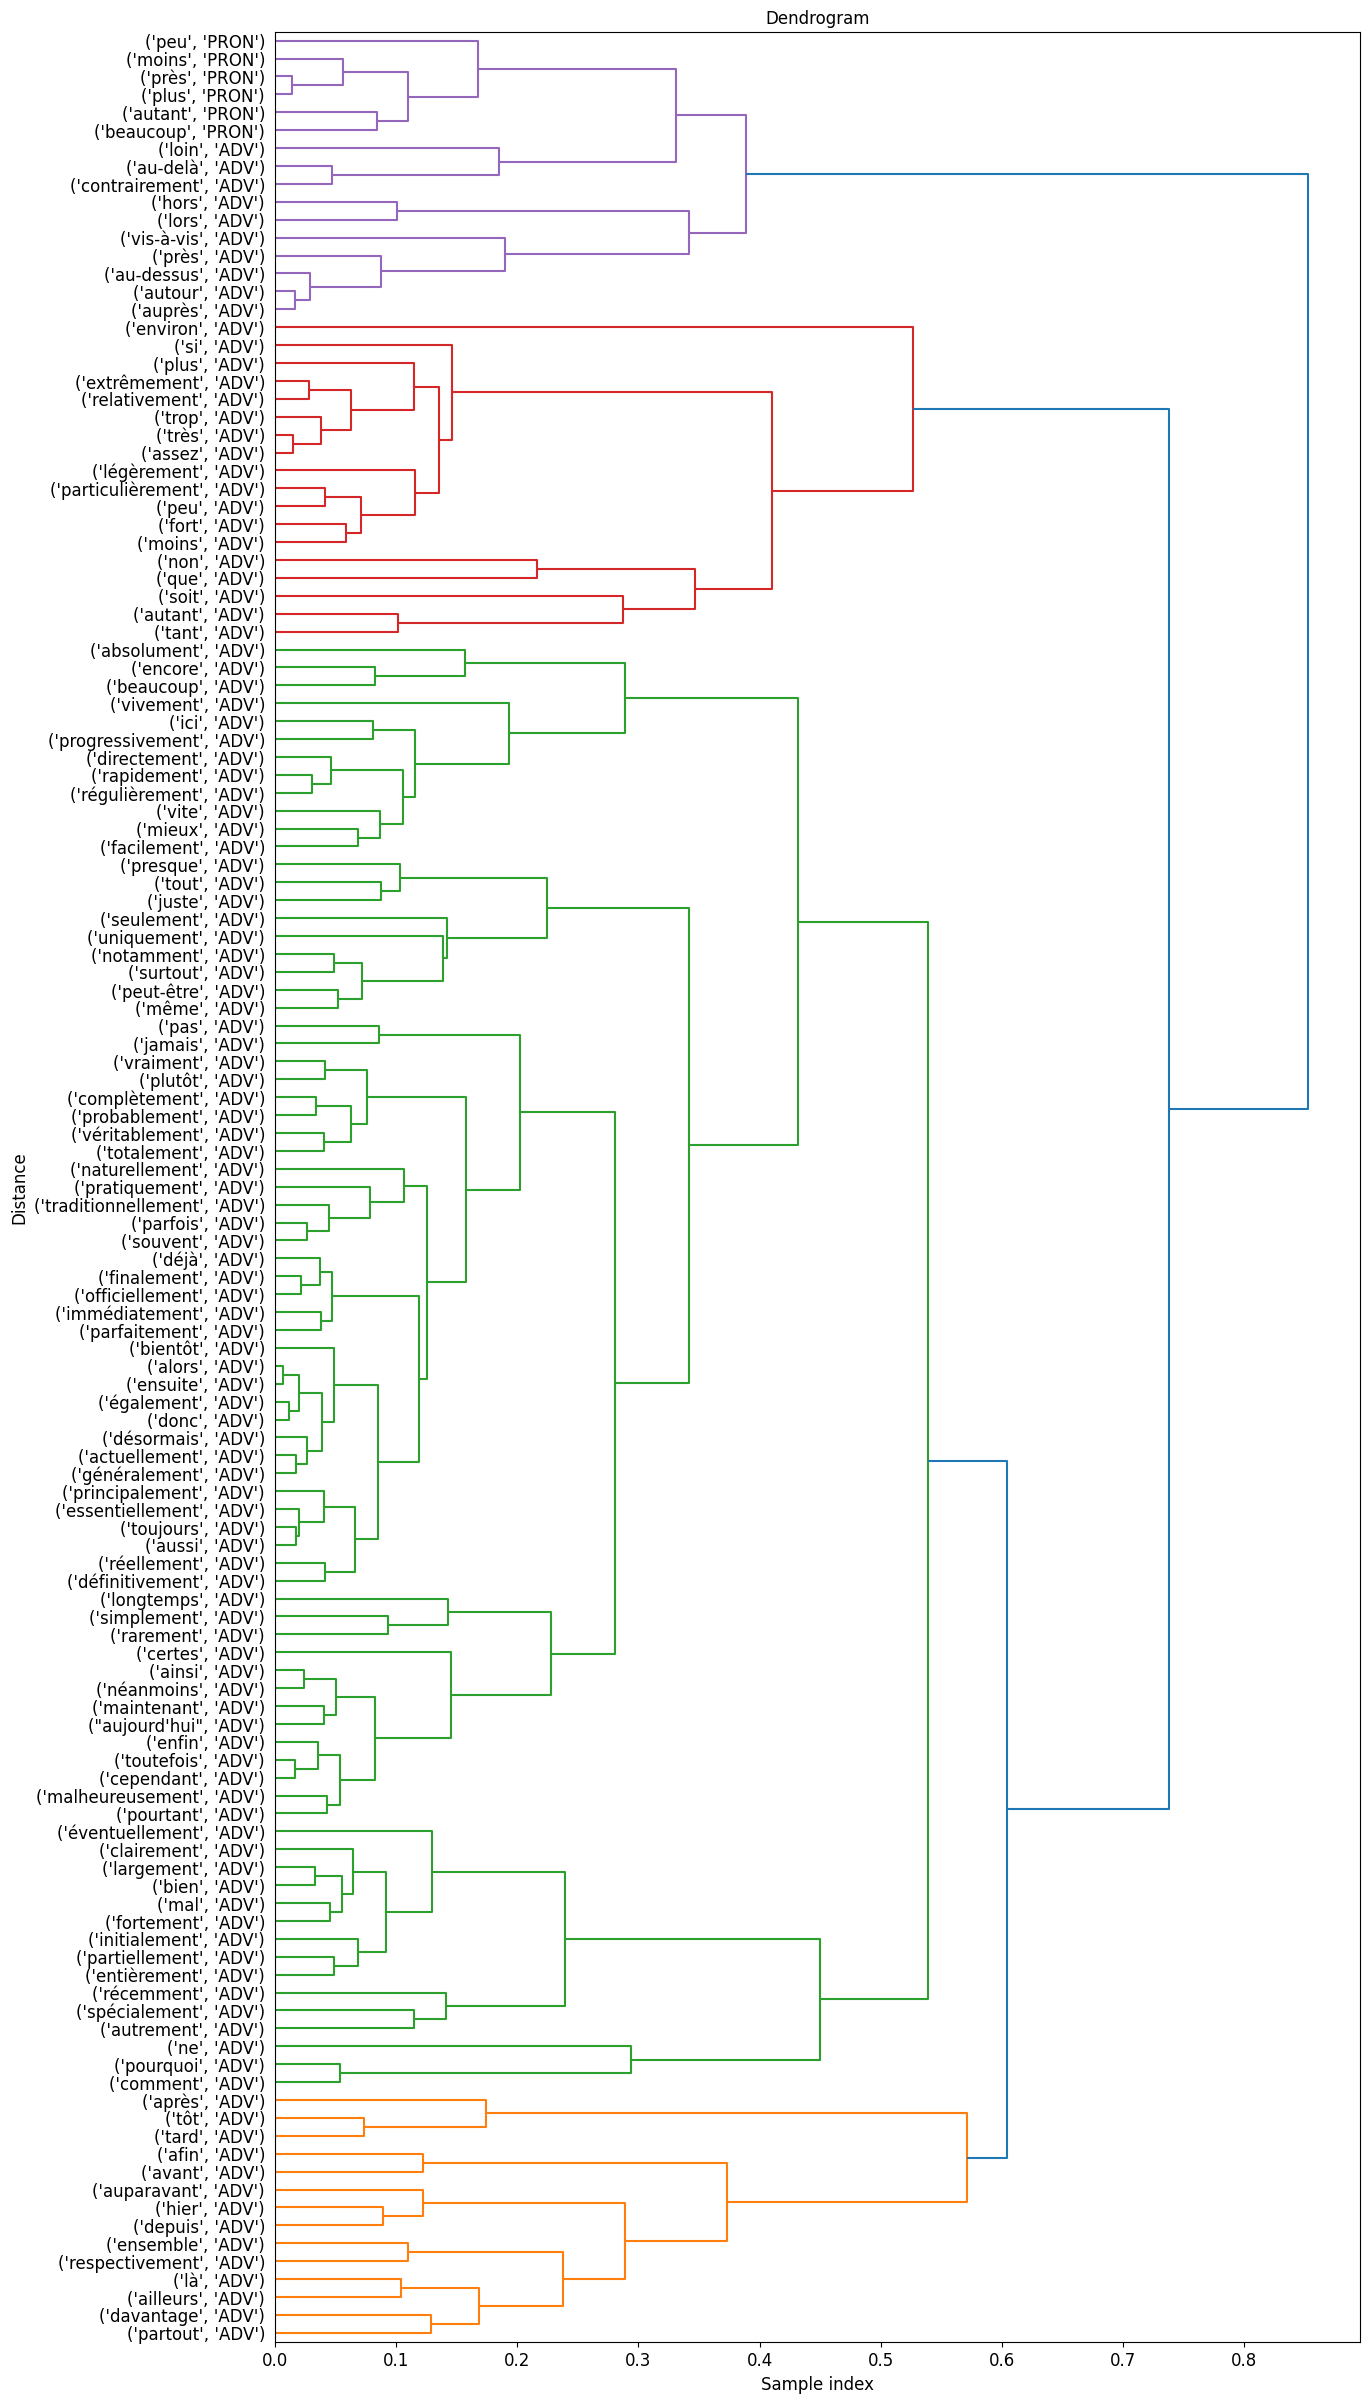

In [57]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

distance_matrix = pdist(X, metric="cosine")
linked = linkage(
            distance_matrix, method="complete", optimal_ordering=True
        ) 


plt.figure(figsize=(14, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X_cleaned.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

if we remove correlated features before doing all the other stuff

In [65]:
import pandas as pd
import numpy as np

X = corpus.feature_matrix
# Convert X to a DataFrame for easier manipulation (if it's not already)
X_df = pd.DataFrame(X, columns=[corpus.idx2feature(idx) for idx in range(X.shape[1])])

# Calculate the correlation matrix
correlation_matrix = X_df.corr().abs()  # Absolute value of correlations

# Identify highly correlated features (correlation > 0.9)
threshold = 0.9
highly_correlated = np.where(correlation_matrix > threshold)
correlated_pairs = [
    (correlation_matrix.index[i], correlation_matrix.columns[j])
    for i, j in zip(*highly_correlated)
    if i != j and i < j  # Avoid self-correlation and duplicate pairs
]

# Create a set of features to remove
features_to_remove_corr = set()
for feature1, feature2 in correlated_pairs:
    # Decide which feature to remove (e.g., keep the one with higher variance)
    if X_df[feature1].var() > X_df[feature2].var():
        features_to_remove_corr.add(feature2)
    else:
        features_to_remove_corr.add(feature1)

# Map features to indices using corpus.feature2idx
indices_to_remove_corr = [corpus.feature2idx(feature) for feature in features_to_remove_corr]

# Remove the columns from X
X_cleaned = np.delete(X, list(indices_to_remove_corr), axis=1)

print(f"Original shape of X: {X.shape}")
print(f"Shape of X after removing highly correlated features: {X_cleaned.shape}")

X = X_cleaned

Original shape of X: (129, 298)
Shape of X after removing highly correlated features: (129, 227)


In [72]:
frequency_matrix = corpus.co_occurrence_matrix
print(frequency_matrix.shape)

# Step 1: Sum the values in each column if column index is not in indices_to_remove
column_sums = np.sum(frequency_matrix[:, [i for i in range(frequency_matrix.shape[1]) if i not in indices_to_remove_corr]], axis=0)

# Step 2: Sort the values and keep track of their original indices
freq_sorted_indices = np.argsort(column_sums)
freq_sorted_values = column_sums[sorted_indices]

(129, 298)


In [73]:
var = np.var(X_pmi[:, indices_to_remove_corr], axis=0)  # Variance for each column
var_sorted_indices = np.argsort(var)  # Get indices that would sort the variance
var_sorted_values = var[var_sorted_indices]  # Sort variances

In [75]:
means = np.mean(frequency_matrix[:, [i for i in range(frequency_matrix.shape[1]) if i not in indices_to_remove_corr]], axis=0)
variances = np.var(frequency_matrix[:, [i for i in range(frequency_matrix.shape[1]) if i not in indices_to_remove_corr]], axis=0)  # Variance for each column
vmr = variances / means
feature_names = [corpus.idx2feature(idx) for idx in range(X.shape[1])]  # Map indices to feature names
vmr_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean": means,
    "Variance": variances,
    "VMR": vmr
})
threshold = 0.1  # Define a threshold for "closeness" to 1
poisson_like_features = vmr_df[np.abs(vmr_df["VMR"] - 1) < threshold]  # Features close to Poisson
non_random_features = vmr_df[np.abs(vmr_df["VMR"] - 1) >= threshold]  # Features significantly non-random

# Display results
print("Features close to Poisson distribution (to be removed):")
print(poisson_like_features)

print("\nFeatures significantly non-random (to be kept):")
print(non_random_features)


Features close to Poisson distribution (to be removed):
                               Feature      Mean  Variance       VMR
2                 node:X:child:Emph=No  0.038760  0.037257  0.961240
4              node:X:child:ExtPos=ADP  0.007752  0.007692  0.992248
6            node:X:child:ExtPos=CCONJ  0.015504  0.015264  0.984496
7             node:X:child:ExtPos=NOUN  0.007752  0.007692  0.992248
8             node:X:child:ExtPos=PRON  0.015504  0.015264  0.984496
11             node:X:child:Gender=Fem  0.023256  0.022715  0.976744
12            node:X:child:Gender=Masc  0.038760  0.037257  0.961240
15               node:X:child:Mood=Sub  0.007752  0.007692  0.992248
20               node:X:child:Person=2  0.015504  0.015264  0.984496
21               node:X:child:Person=3  0.038760  0.037257  0.961240
27           node:X:child:PronType=Ind  0.054264  0.051319  0.945736
29           node:X:child:PronType=Prs  0.007752  0.007692  0.992248
34     node:X:child:Subject=OblRaising  0.00775

In [78]:
indices = freq_sorted_indices
values = freq_sorted_values
items = [corpus.idx2feature(idx) for idx in indices]
frequency_df = pd.DataFrame({
    "Feature": [i.split("=")[0] for i in items],
    "Value": [i.split("=")[1] for i in items],
    "Frequency": values
})

frequency_df

# # Define lower and upper bounds
lower_bound = 100
upper_bound = 4500

clean_frequency_df = frequency_df[(frequency_df['Frequency'] >= lower_bound) & (frequency_df['Frequency'] <= upper_bound)]
clean_frequency_df

,Feature,Value,Frequency
136,node:X:next:Subject,OblRaising,104.0
137,node:X:child:upos,X,111.0
138,node:X:next:upos,NOUN,113.0
139,node:X:parent:PronType,Ind,115.0
140,node:X:child:Mood,Cnd,116.0
...,...,...,...
216,node:X:own:rel_shallow,conj,3178.0
217,node:X:own:rel_shallow,nmod,3753.0
218,node:X:own:rel_shallow,obl:agent,3905.0
219,node:X:next:upos,ADP,3934.0


In [79]:
# Identify features with exactly two possible values
two_value_features = clean_frequency_df.groupby('Feature')['Value'].nunique()
two_value_features = two_value_features[two_value_features == 2].index

# Filter the DataFrame to exclude one of the two possible values for these features
clean_frequency_df = clean_frequency_df[
    ~(
        (clean_frequency_df['Feature'].isin(two_value_features)) &
        (clean_frequency_df.duplicated(subset=['Feature'], keep='first'))
    )
]

clean_frequency_df

,Feature,Value,Frequency
136,node:X:next:Subject,OblRaising,104.0
137,node:X:child:upos,X,111.0
138,node:X:next:upos,NOUN,113.0
139,node:X:parent:PronType,Ind,115.0
140,node:X:child:Mood,Cnd,116.0
...,...,...,...
216,node:X:own:rel_shallow,conj,3178.0
217,node:X:own:rel_shallow,nmod,3753.0
218,node:X:own:rel_shallow,obl:agent,3905.0
219,node:X:next:upos,ADP,3934.0


In [80]:
# Find the rows that were removed
removed_df = pd.merge(
    frequency_df,  # Original DataFrame
    clean_frequency_df,  # Cleaned DataFrame
    how='outer',  # Include all rows from both DataFrames
    indicator=True  # Add a column to indicate the source of each row
)

# Filter rows that are only in the original DataFrame
frequency_removed_df = removed_df[removed_df['_merge'] == 'left_only'].drop(columns=['_merge'])

frequency_removed_df

,Feature,Value,Frequency
0,node:X:next:Person,1,1.0
1,node:X:child:PronType,Prs,1.0
2,node:X:child:Mood,Sub,1.0
3,node:X:own:Polarity,Pos,1.0
4,node:X:next:Subject,Generic,1.0
...,...,...,...
222,node:X:parent:Number,Plur,5367.0
223,node:X:parent:Definite,Ind,6928.0
224,node:X:next:upos,INTJ,7511.0
225,node:X:own:rel_shallow,obj:lvc,7796.0


In [81]:
indices = var_sorted_indices
values = var_sorted_values
items = [corpus.idx2feature(idx) for idx in indices]
var_df = pd.DataFrame({
    "Feature": [i.split("=")[0] for i in items],
    "Value": [i.split("=")[1] for i in items],
    "Variance": values,
    # "Z-Variance (PMI)": z_var_sorted_values
})

num_rows = len(var_df)
first_25_percent = int(num_rows * 0.25)
filtered_variance_df = var_df[
    var_df['Variance'] >= var_df['Variance'].iloc[first_25_percent]
]

print(filtered_variance_df)

                      Feature        Value  Variance
17   node:X:child:rel_shallow        ccomp  0.248360
18          node:X:child:Poss          Yes  0.252949
19        node:X:child:ExtPos        SCONJ  0.261557
20   node:X:child:rel_shallow      obl:mod  0.262832
21       node:X:child:Subject   OblRaising  0.262832
22          node:X:child:Mood          Cnd  0.266056
23          node:X:child:Emph          Yes  0.284300
24      node:X:child:Definite          Ind  0.299434
25   node:X:child:rel_shallow  advcl:cleft  0.303149
26   node:X:child:rel_shallow    acl:relcl  0.314627
27        node:X:child:Gender          Fem  0.320886
28   node:X:child:rel_shallow     goeswith  0.329452
29   node:X:child:rel_shallow        appos  0.350725
30   node:X:child:rel_shallow          obj  0.350786
31      node:X:child:PronType          Prs  0.357323
32        node:X:child:ExtPos        CCONJ  0.365114
33   node:X:child:rel_shallow         conj  0.377738
34       node:X:child:Subject      Generic  0.

In [82]:
removed_df = pd.merge(
    var_df,  # Original DataFrame
    filtered_variance_df,  # Cleaned DataFrame
    how='outer',  # Include all rows from both DataFrames
    indicator=True  # Add a column to indicate the source of each row
)

# Filter rows that are only in the original DataFrame
var_removed_df = removed_df[removed_df['_merge'] == 'left_only'].drop(columns=['_merge'])

var_removed_df

,Feature,Value,Variance
0,node:X:child:rel_shallow,dep,0.024620
1,node:X:child:Voice,Act,0.024620
2,node:X:child:ExtPos,PRON,0.024620
3,node:X:child:Subject,SubjRaising,0.025408
4,node:X:child:rel_shallow,cc,0.132210
5,node:X:child:rel_shallow,cop,0.134662
6,node:X:child:rel_shallow,flat:name,0.134662
7,node:X:child:Subject,ObjRaising,0.153795
8,node:X:child:VerbForm,Inf,0.161832
9,node:X:child:Person,1,0.170366


In [83]:
combined_removed_df = pd.DataFrame({
    "Feature_frequency": frequency_removed_df["Feature"] + "=" + frequency_removed_df["Value"],
    "Feature_variance": var_removed_df["Feature"] + "=" + var_removed_df["Value"],
    "Feature_non_randomness": poisson_like_features["Feature"]
})

In [84]:
# Convert each column to a set
frequency_set = set(combined_removed_df["Feature_frequency"].dropna())
variance_set = set(combined_removed_df["Feature_variance"].dropna())
non_randomness_set = set(combined_removed_df["Feature_non_randomness"].dropna())

# Find intersections and differences
all_three = frequency_set & variance_set & non_randomness_set
frequency_variance_only = (frequency_set & variance_set) - non_randomness_set
frequency_non_randomness_only = (frequency_set & non_randomness_set) - variance_set
variance_non_randomness_only = (variance_set & non_randomness_set) - frequency_set
frequency_only = frequency_set - (variance_set | non_randomness_set)
variance_only = variance_set - (frequency_set | non_randomness_set)
non_randomness_only = non_randomness_set - (frequency_set | variance_set)

# Find the maximum length among all sets
max_length = max(
    len(all_three),
    len(frequency_variance_only),
    len(frequency_non_randomness_only),
    len(variance_non_randomness_only),
    len(frequency_only),
    len(variance_only),
    len(non_randomness_only)
)

# Pad each list with None to match the maximum length
summary_df = pd.DataFrame({
    "All_three": list(all_three) + [None] * (max_length - len(all_three)),
    "Frequency_and_Variance_only": list(frequency_variance_only) + [None] * (max_length - len(frequency_variance_only)),
    "Frequency_and_Non_randomness_only": list(frequency_non_randomness_only) + [None] * (max_length - len(frequency_non_randomness_only)),
    "Variance_and_Non_randomness_only": list(variance_non_randomness_only) + [None] * (max_length - len(variance_non_randomness_only)),
    "Frequency_only": list(frequency_only) + [None] * (max_length - len(frequency_only)),
    "Variance_only": list(variance_only) + [None] * (max_length - len(variance_only)),
    "Non_randomness_only": list(non_randomness_only) + [None] * (max_length - len(non_randomness_only))
})

summary_df

,All_three,Frequency_and_Variance_only,Frequency_and_Non_randomness_only,Variance_and_Non_randomness_only,Frequency_only,Variance_only,Non_randomness_only
0,node:X:child:ExtPos=PRON,node:X:child:Subject=SubjRaising,node:X:own:rel_shallow=obl:mod,None,node:X:child:rel_shallow=acl:relcl,node:X:child:rel_shallow=dep,None
1,node:X:child:VerbForm=Inf,node:X:child:rel_shallow=flat:name,node:X:child:Gender=Masc,None,node:X:next:upos=PROPN,node:X:child:rel_shallow=cop,None
2,node:X:child:ExtPos=ADP,node:X:child:rel_shallow=expl:subj,node:X:next:Tense=Imp,None,node:X:next:VerbForm=Inf,None,None
3,None,node:X:child:Subject=ObjRaising,node:X:next:Voice=Pass,None,node:X:child:rel_shallow=conj,None,None
4,None,node:X:child:rel_shallow=mark,node:X:next:Subject=Instantiated,None,node:X:child:upos=CCONJ,None,None
...,...,...,...,...,...,...,...
99,None,None,None,None,node:X:child:rel_shallow=orphan,None,None
100,None,None,None,None,node:X:child:upos=VERB,None,None
101,None,None,None,None,node:X:next:VerbForm=Part,None,None
102,None,None,None,None,node:X:child:VerbForm=Fin,None,None


In [85]:
# Combine all features from the summary table into a single set
features_to_remove = set(
    summary_df["All_three"].dropna().tolist() +
    summary_df["Frequency_and_Variance_only"].dropna().tolist() +
    summary_df["Frequency_and_Non_randomness_only"].dropna().tolist() +
    summary_df["Variance_and_Non_randomness_only"].dropna().tolist() +
    summary_df["Frequency_only"].dropna().tolist() +
    summary_df["Variance_only"].dropna().tolist() +
    summary_df["Non_randomness_only"].dropna().tolist()
)

# Get the indices of features to remove using corpus.feature2idx
indices_to_remove = [corpus.feature2idx(feature) for feature in features_to_remove]

# Remove the columns from X
X_cleaned = np.delete(X, indices_to_remove, axis=1)  # axis=1 removes columns

print(f"Original shape of X: {X.shape}")
print(f"Shape of X after removal: {X_cleaned.shape}")

Original shape of X: (129, 227)
Shape of X after removal: (129, 77)


In [94]:
len(indices_to_remove)

150

In [105]:
X = corpus.feature_matrix
removed_indices = indices_to_remove + indices_to_remove_corr
kept_features = set([corpus.idx2feature(i) for i in range(X.shape[1]) if i not in removed_indices])

In [106]:
len(kept_features)

122

In [103]:
# Split the list elements into Feature and Value
parsed_features = [item.split("=") for item in kept_features]
parsed_df = pd.DataFrame(parsed_features, columns=["Feature", "Value"])

# Merge with the original DataFrame
merged_df = pd.merge(parsed_df, frequency_df, on=["Feature", "Value"], how="inner")

# Display the resulting DataFrame
merged_df

,Feature,Value,Frequency
0,node:X:child:ExtPos,PROPN,464.0
1,node:X:child:Mood,Cnd,116.0
2,node:X:child:PronType,Rel,182.0
3,node:X:child:Tense,Past,403.0
4,node:X:child:rel_shallow,ccomp,290.0
...,...,...,...
63,node:X:parent:VerbForm,Fin,945.0
64,node:X:parent:VerbForm,Inf,1925.0
65,node:X:parent:Voice,Act,420.0
66,node:X:parent:position,before,789.0


In [101]:
kept_features_with_criteria

,Feature,Frequency
0,node:X:child:ExtPos=PROPN,"Series([], Name: Frequency, dtype: float64)"
1,node:X:child:Mood=Cnd,"Series([], Name: Frequency, dtype: float64)"
2,node:X:child:PronType=Rel,"Series([], Name: Frequency, dtype: float64)"
3,node:X:child:Tense=Past,"Series([], Name: Frequency, dtype: float64)"
4,node:X:child:rel_shallow=ccomp,"Series([], Name: Frequency, dtype: float64)"
...,...,...
117,node:X:prev:upos=PROPN,"Series([], Name: Frequency, dtype: float64)"
118,node:X:prev:upos=PUNCT,"Series([], Name: Frequency, dtype: float64)"
119,node:X:prev:upos=SCONJ,"Series([], Name: Frequency, dtype: float64)"
120,node:X:prev:upos=VERB,"Series([], Name: Frequency, dtype: float64)"


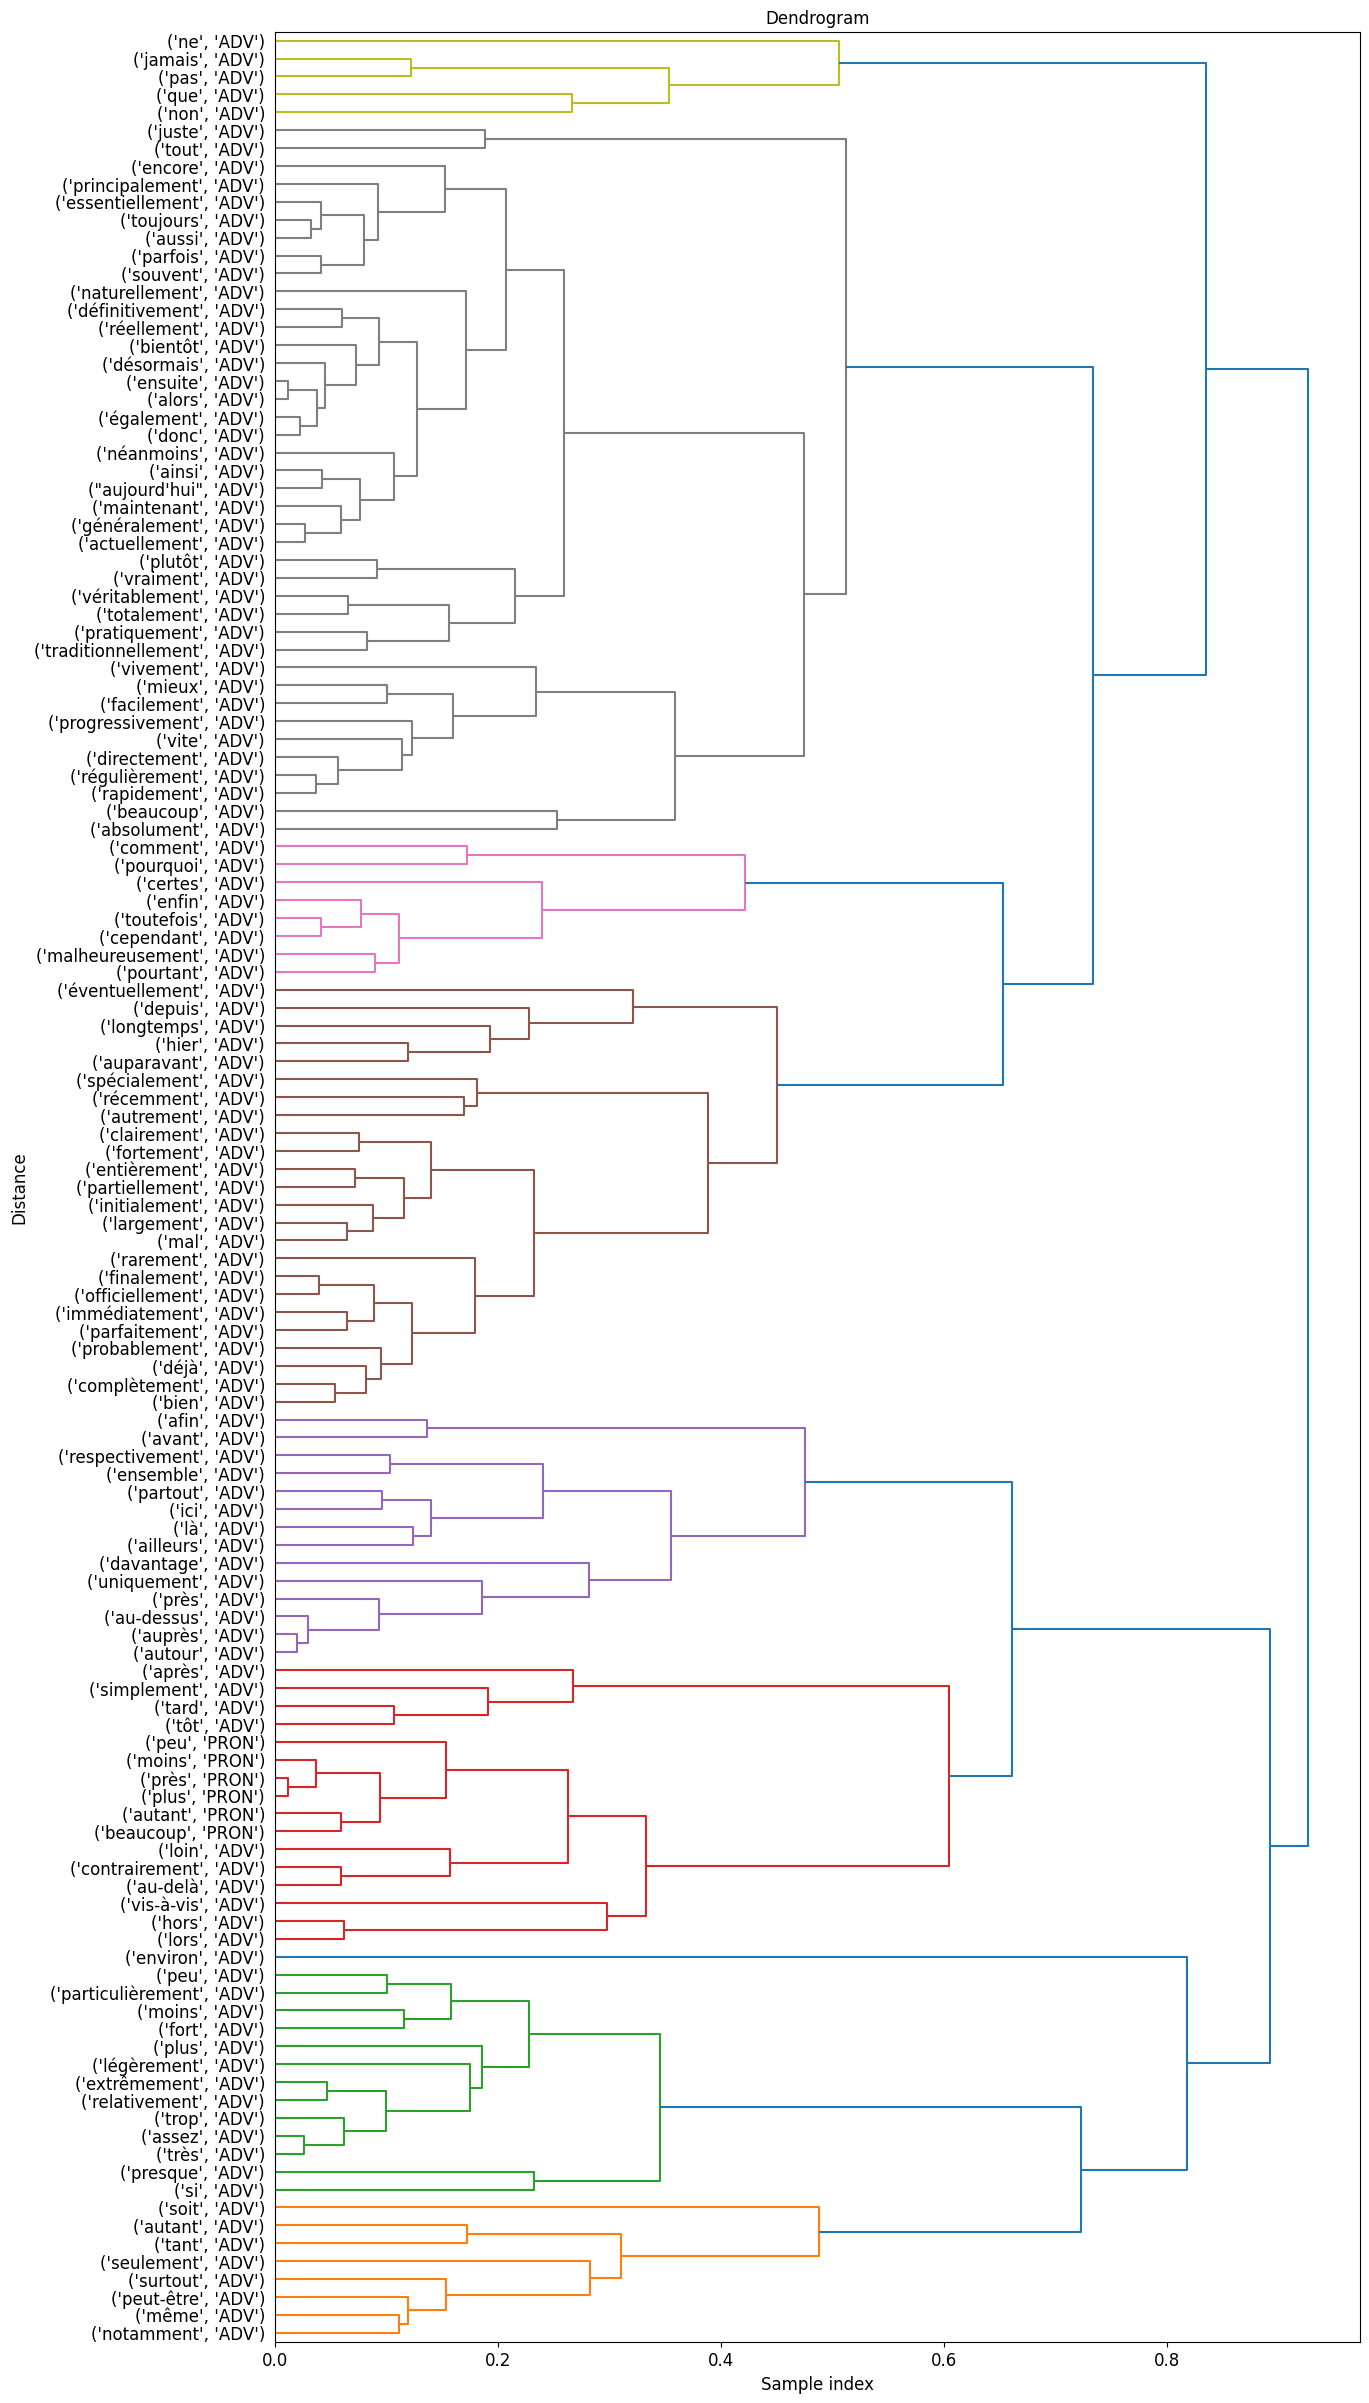

In [86]:
distance_matrix = pdist(X_cleaned, metric="cosine")
linked = linkage(
            distance_matrix, method="complete", optimal_ordering=True
        ) 


plt.figure(figsize=(14, 30))

dn = dendrogram(linked,
                orientation='right',
                labels=[corpus.idx2lexunit(i) for i in range(X_cleaned.shape[0])],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()